In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import  warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from catboost import CatBoostRegressor
from xgboost import XGBRegressor


In [4]:
df = pd.read_csv("data/modified_data.csv")
df.head()

,Unnamed: 0,gender,race/ethnicity,parental level of education,lunch,test preparation course,Total_score
0,0,female,group B,bachelor's degree,standard,none,72.666667
1,1,female,group C,some college,standard,completed,82.333333
2,2,female,group B,master's degree,standard,none,92.666667
3,3,male,group A,associate's degree,free/reduced,none,49.333333
4,4,male,group C,some college,standard,none,76.333333


# Seperate dependent and Independent Feature

In [5]:
x = df.drop(['Total_score'], axis=1)
y = df['Total_score']

In [6]:
x

,Unnamed: 0,gender,race/ethnicity,parental level of education,lunch,test preparation course
0,0,female,group B,bachelor's degree,standard,none
1,1,female,group C,some college,standard,completed
2,2,female,group B,master's degree,standard,none
3,3,male,group A,associate's degree,free/reduced,none
4,4,male,group C,some college,standard,none
...,...,...,...,...,...,...
995,995,female,group E,master's degree,standard,completed
996,996,male,group C,high school,free/reduced,none
997,997,female,group C,high school,free/reduced,completed
998,998,female,group D,some college,standard,completed


In [7]:
y

0      72.666667
1      82.333333
2      92.666667
3      49.333333
4      76.333333
         ...    
995    94.000000
996    57.333333
997    65.000000
998    74.333333
999    83.000000
Name: Total_score, Length: 1000, dtype: float64

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_feature = x.select_dtypes(exclude='object').columns
cat_feature = x.select_dtypes(include='object').columns

print(num_feature)
print(cat_feature)

Index(['Unnamed: 0'], dtype='object')
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


In [9]:
x= x.drop(columns=num_feature)

In [10]:
x.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course
0,female,group B,bachelor's degree,standard,none
1,female,group C,some college,standard,completed
2,female,group B,master's degree,standard,none
3,male,group A,associate's degree,free/reduced,none
4,male,group C,some college,standard,none


In [11]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25)

In [12]:
x_train

,gender,race/ethnicity,parental level of education,lunch,test preparation course
335,female,group B,some college,free/reduced,none
500,female,group D,master's degree,standard,none
880,male,group C,bachelor's degree,standard,completed
422,female,group D,master's degree,free/reduced,completed
37,female,group D,high school,free/reduced,none
...,...,...,...,...,...
113,female,group D,some college,standard,none
157,male,group B,some college,free/reduced,none
615,female,group C,high school,standard,none
461,male,group B,some college,free/reduced,none


In [13]:
ohe = OneHotEncoder()
x_train = ohe.fit_transform(x_train)
x_test = ohe.transform(x_test)

In [14]:
print(x_train[:5].toarray())

[[1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1.]
 [1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1.]
 [0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0.]
 [1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0.]
 [1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1.]]


In [15]:
x_train.shape

(750, 16)

# Create an Evaluate Function to give all metrics after Model Training

In [16]:
def evaluate_metrics(true, predicted):
    print("="*50)
    print("r2_score: ", r2_score(true, predicted))
    print("="*50)
    print("mean squared error: ", mean_squared_error(true, predicted))
    print("=" * 50)
    print("root mean squared error: ", np.sqrt(mean_squared_error(true, predicted)))
    print("=" * 50)
    print("mean absolute error: ", mean_absolute_error(true, predicted))
    print("=" * 50)

In [17]:
models = {
    'LinearRegression' : LinearRegression(),
    'Lasso' : Lasso(),
    'Ridge' : Ridge(),
    'RandomForestRegressor' : RandomForestRegressor(),
    'KNeighborsRegressor' : KNeighborsRegressor(),
    'DecisionTreeRegressor' : DecisionTreeRegressor(),
    'XGBRegressor' : XGBRegressor(),
    'CatBoostRegressor' : CatBoostRegressor(verbose=False),
    'AdaBoostRegressor' : AdaBoostRegressor()
}

for i in models.keys():
    model = models[i]
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print("Model: ", i)
    evaluate_metrics(y_test, y_pred)

Model:  LinearRegression
r2_score:  0.20724768974453112
mean squared error:  187.66952281047358
root mean squared error:  13.69925263693146
mean absolute error:  10.774370683408273
Model:  Lasso
r2_score:  0.10781434715668337
mean squared error:  211.20853709464294
root mean squared error:  14.533015416445513
mean absolute error:  11.34481887419251
Model:  Ridge
r2_score:  0.2077932928615005
mean squared error:  187.54036131162843
root mean squared error:  13.694537645047694
mean absolute error:  10.770691281442334


Model:  RandomForestRegressor
r2_score:  0.02206885954267246
mean squared error:  231.5072035702879
root mean squared error:  15.215360776869142
mean absolute error:  11.873947098805226
Model:  KNeighborsRegressor
r2_score:  0.0350129288471277
mean squared error:  228.44293333333334
root mean squared error:  15.11432874239982
mean absolute error:  11.572533333333332
Model:  DecisionTreeRegressor
r2_score:  -0.022403178554158742
mean squared error:  242.0351403042117
root mean squared error:  15.55747859726028
mean absolute error:  12.024145993772311
Model:  XGBRegressor
r2_score:  -0.027024996942787816
mean squared error:  243.1292707662613
root mean squared error:  15.59260307858381
mean absolute error:  12.115797292073568
Model:  CatBoostRegressor
r2_score:  0.0026230578092460988
mean squared error:  236.1106393279247
root mean squared error:  15.365892077192417
mean absolute error:  11.934314356642236
Model:  AdaBoostRegressor
r2_score:  0.183033353528261
mean squared error:  193.40

In [18]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
pred_diff = pd.DataFrame({'Actual value': y_test, 'predicted value': y_pred, 'Difference' : y_test-y_pred})
pred_diff


,Actual value,predicted value,Difference
404,58.333333,65.594374,-7.261041
596,23.000000,53.461713,-30.461713
862,39.666667,72.999092,-33.332425
402,56.333333,57.665719,-1.332386
694,56.000000,65.594374,-9.594374
...,...,...,...
796,70.000000,64.504398,5.495602
736,85.000000,65.630634,19.369366
92,73.666667,61.718358,11.948308
223,80.333333,64.504398,15.828935


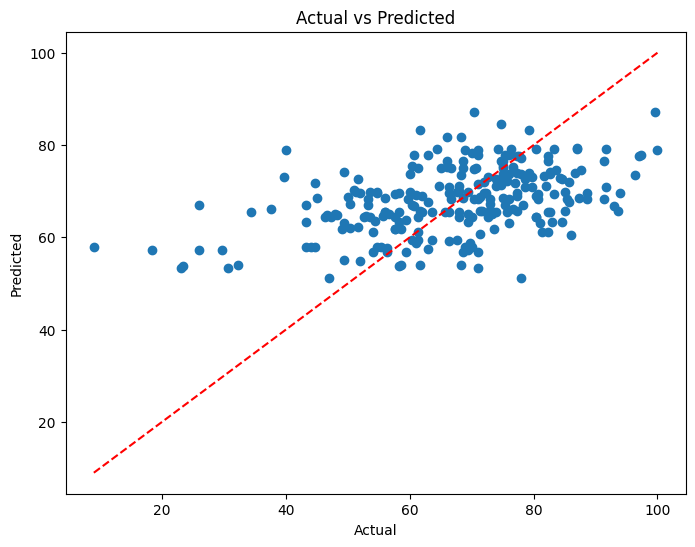

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


In [20]:
print("Actual mean:", y_test.mean())
print("Predicted mean:", y_pred.mean())

print("Actual std:", y_test.std())
print("Predicted std:", y_pred.std())


Actual mean: 67.15333333333334
Predicted mean: 68.09124215926268
Actual std: 15.416949416705924
Predicted std: 7.213477926386187


## Observation:
1) Here we tried to predict average score considering only the demographic feature, and its pretty obvious that you will get a large error if you try to predict the score only based on demographic feature. There may also be possibility that there are two students both female both group B with high school studies and with standard lunch but gets completly different score
2) If we want more correlation we can keep one subject score as target and use scores of other two subject as feature which will give us a higher relation on the score of the target

In [21]:
df = pd.read_csv('data/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [22]:
df["parental level of education"] = df["parental level of education"].replace(
    "some high school", "high school"
)


In [23]:
x = df.drop(columns='math score')
y = df['math score']

In [24]:
x

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [25]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [26]:
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size=0.25, random_state= 42)

In [27]:
num_feature = x.select_dtypes(exclude='object').columns
cat_feature = x.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    [
        ('StandardScaler', StandardScaler(), num_feature),
        ('OneHotEncoder', OneHotEncoder(), cat_feature)
    ], remainder= 'passthrough'
)

x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

In [28]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "RandomForestRegressor": RandomForestRegressor(),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoostRegressor": CatBoostRegressor(verbose=False),
    "AdaBoostRegressor": AdaBoostRegressor(),
}

for i in models.keys():
    model = models[i]
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print("Model: ", i)
    evaluate_metrics(y_test, y_pred)


Model:  LinearRegression
r2_score:  0.8779568250123724
mean squared error:  30.025512982030907
root mean squared error:  5.479554086057633
mean absolute error:  4.334162431988379
Model:  Lasso
r2_score:  0.8202484185317581
mean squared error:  44.22314843466199
root mean squared error:  6.650048754307143
mean absolute error:  5.218405738075968
Model:  Ridge
r2_score:  0.8781206659162256
mean squared error:  29.985204237308945
root mean squared error:  5.475874746313044
mean absolute error:  4.331435987806164
Model:  RandomForestRegressor
r2_score:  0.8509566319195995
mean squared error:  36.668200279428575
root mean squared error:  6.055427340776914
mean absolute error:  4.759128952380953
Model:  KNeighborsRegressor
r2_score:  0.7949004066665188
mean squared error:  50.459360000000004
root mean squared error:  7.1034752058411526
mean absolute error:  5.6456
Model:  DecisionTreeRegressor
r2_score:  0.7605921666992597
mean squared error:  58.9
root mean squared error:  7.674633541739957


In [29]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
pred_diff = pd.DataFrame(
    {"Actual value": y_test, "predicted value": y_pred, "Difference": y_test - y_pred}
)
pred_diff


,Actual value,predicted value,Difference
521,91,76.420431,14.579569
737,53,58.835943,-5.835943
740,80,76.906651,3.093349
660,74,76.768207,-2.768207
411,84,87.446861,-3.446861
...,...,...,...
109,70,64.165775,5.834225
430,64,63.166849,0.833151
77,80,82.711995,-2.711995
84,42,39.287192,2.712808


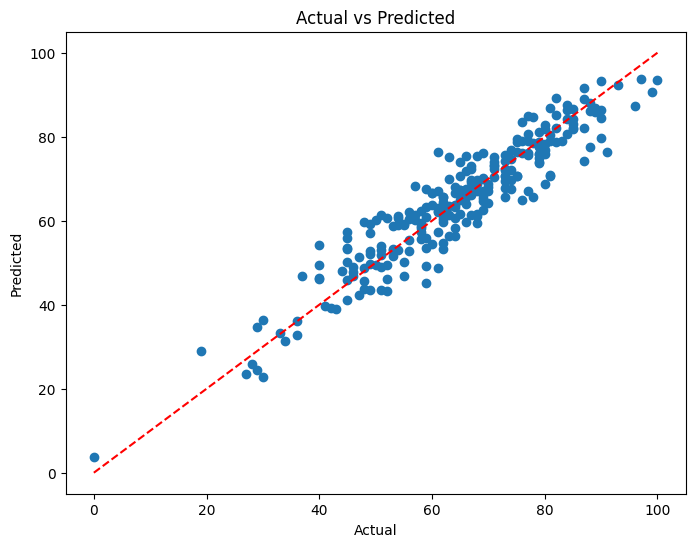

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


In [31]:
print("Actual mean:", y_test.mean())
print("Predicted mean:", y_pred.mean())

print("Actual std:", y_test.std())
print("Predicted std:", y_pred.std())


Actual mean: 64.548
Predicted mean: 64.59988007470992
Actual std: 15.716607234765636
Predicted std: 14.881695485635719


## Observation 
We can see a much better model when we keep 2 scores as feature